# Notebook 05 — Treinamento de uma Rede com NumPy

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- calcular previsões e MSE;
- derivar e aplicar gradientes;
- implementar Gradient Descent e backpropagation;
- treinar uma rede 2 → 3 → 1 sem TensorFlow.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


LOSS

  ↓

GRADIENTE

  ↓

BACKPROPAGATION

  ↓
  
GRADIENT DESCENT

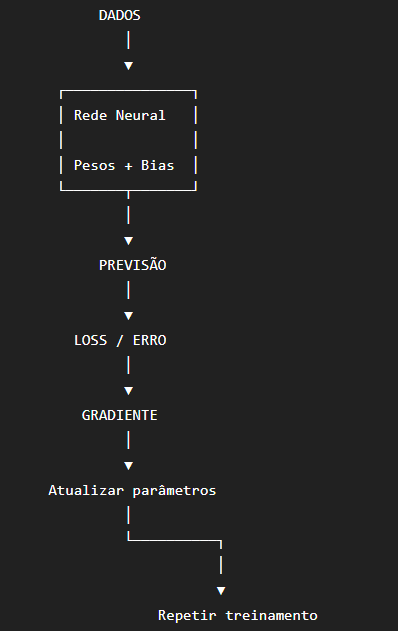

Primeiro passo é criar o modelo

In [1]:
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([3, 5, 7, 9, 11, 13], dtype=float)

peso = 0.0
bias = 0.0

In [2]:
previsao = peso * x + bias

print(previsao)

[0. 0. 0. 0. 0. 0.]


Segundo passo é calcular o erro

Vamos usar uma função chamada Mean Squared Error (MSE) para calcular o erro

Erro = média dos erros ao quadrado

In [3]:
erro = previsao - y

loss = np.mean(erro ** 2)

print("Loss:", loss)

Loss: 75.66666666666667


Terceiro passo: Gradient Descent

y_pred = peso × x + bias

As derivadas do MSE em relação aos parâmetros são:

dLoss/dPeso e dLoss/dBias

In [4]:
grad_peso = (2 / len(x)) * np.sum((previsao - y) * x)

grad_bias = (2 / len(x)) * np.sum(previsao - y)

print("Gradiente do peso:", grad_peso)
print("Gradiente do bias:", grad_bias)

Gradiente do peso: -67.66666666666666
Gradiente do bias: -16.0


Quarto passo: Learning Rate

Precisamos definir o tamanho do passo que o modelo dará.

Por exemplo: learning_rate = 0.01

peso = peso - learning_rate * grad_peso

bias = bias - learning_rate * grad_bias

Novo parâmetro

é igual

Parâmetro atual

menos

Learning Rate × Gradiente

In [5]:
peso = 0.0
bias = 0.0

learning_rate = 0.01

for epoch in range(1000):

    # 1. Previsão
    previsao = peso * x + bias

    # 2. Erro
    erro = previsao - y

    # 3. Loss
    loss = np.mean(erro ** 2)

    # 4. Gradientes
    grad_peso = (2 / len(x)) * np.sum(erro * x)
    grad_bias = (2 / len(x)) * np.sum(erro)

    # 5. Atualização
    peso = peso - learning_rate * grad_peso
    bias = bias - learning_rate * grad_bias

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.4f} | "
            f"Peso: {peso:.4f} | "
            f"Bias: {bias:.4f}"
        )

Epoch: 0 | Loss: 75.6667 | Peso: 0.6767 | Bias: 0.1600
Epoch: 100 | Loss: 0.0236 | Peso: 2.0816 | Bias: 0.6507
Epoch: 200 | Loss: 0.0114 | Peso: 2.0566 | Bias: 0.7577
Epoch: 300 | Loss: 0.0055 | Peso: 2.0393 | Bias: 0.8319
Epoch: 400 | Loss: 0.0026 | Peso: 2.0272 | Bias: 0.8834
Epoch: 500 | Loss: 0.0013 | Peso: 2.0189 | Bias: 0.9191
Epoch: 600 | Loss: 0.0006 | Peso: 2.0131 | Bias: 0.9439
Epoch: 700 | Loss: 0.0003 | Peso: 2.0091 | Bias: 0.9611
Epoch: 800 | Loss: 0.0001 | Peso: 2.0063 | Bias: 0.9730
Epoch: 900 | Loss: 0.0001 | Peso: 2.0044 | Bias: 0.9813


Estamos treinando um modelo sem TensorFlow.

Inicializar pesos

       ↓

Fazer previsão

       ↓

Calcular Loss

       ↓

Calcular Gradientes

       ↓

Atualizar pesos

       ↓
Repetir 1000 vezes

Loss: diminuindo

Peso: aproximando de 2

Bias: aproximando de 1

In [6]:
print("Peso final:", peso)
print("Bias final:", bias)

nova_entrada = 10

previsao_final = peso * nova_entrada + bias

print("Previsão para 10:", previsao_final)

Peso final: 2.0030488163849736
Bias final: 0.9869474118666618
Previsão para 10: 21.017435575716398


In [9]:
import numpy as np

# Dados
x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([3, 5, 7, 9, 11, 13], dtype=float)

# Parâmetros iniciais
peso = 0.0
bias = 0.0

# Taxa de aprendizado
learning_rate = 0.001

# Histórico do treinamento
historico_loss = []
historico_peso = []
historico_bias = []

# Treinamento
for epoch in range(5000):

    # 1. Fazer previsão
    previsao = peso * x + bias

    # 2. Calcular erro
    erro = previsao - y

    # 3. Calcular Loss
    loss = np.mean(erro ** 2)

    # Guardar histórico
    historico_loss.append(loss)
    historico_peso.append(peso)
    historico_bias.append(bias)

    # 4. Calcular gradientes
    grad_peso = (2 / len(x)) * np.sum(erro * x)
    grad_bias = (2 / len(x)) * np.sum(erro)

    # 5. Atualizar parâmetros
    peso = peso - learning_rate * grad_peso
    bias = bias - learning_rate * grad_bias


print("Peso final:", peso)
print("Bias final:", bias)

Peso final: 2.0190261628793467
Bias final: 0.9185452200250934


Adicionando um gráfico de Loss

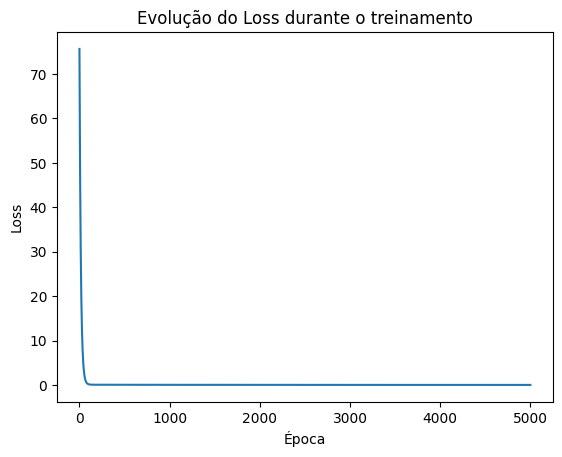

In [10]:
import matplotlib.pyplot as plt

plt.plot(historico_loss)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title("Evolução do Loss durante o treinamento")

plt.show()

Visualizando o Peso

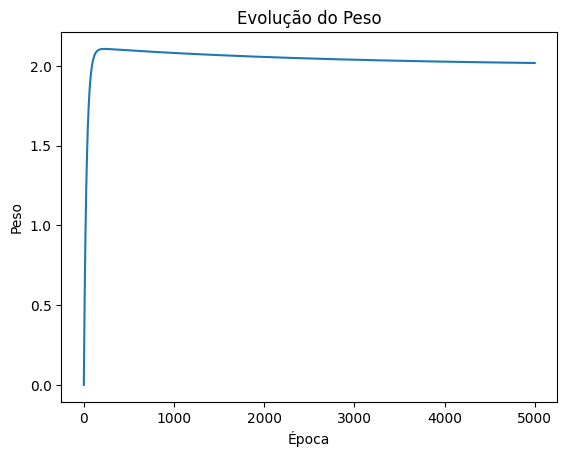

In [11]:
plt.plot(historico_peso)

plt.xlabel("Época")
plt.ylabel("Peso")

plt.title("Evolução do Peso")

plt.show()

Visualizando o Bias

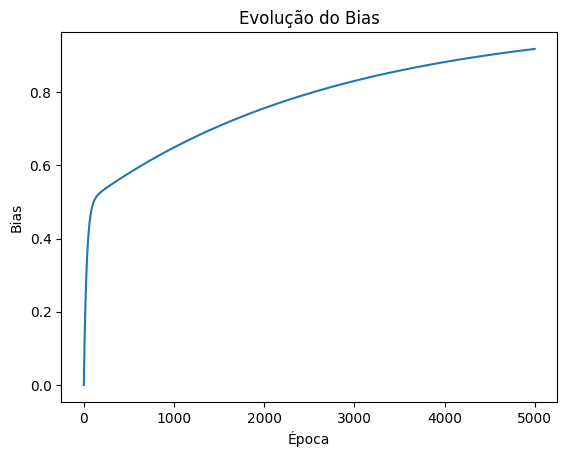

In [12]:
plt.plot(historico_bias)

plt.xlabel("Época")
plt.ylabel("Bias")

plt.title("Evolução do Bias")

plt.show()

Rede Neural / Modelo

       ↓
Aprende os parâmetros

       ↓
Minimiza o erro

       ↓
Faz previsões

Implementando BACKPROPAGATION

Entrada

   ↓
Camada 1

   ↓
ReLU

   ↓
Camada 2

   ↓
Saída

E calcular manualmente: ∂Loss/∂W  para cada camada.

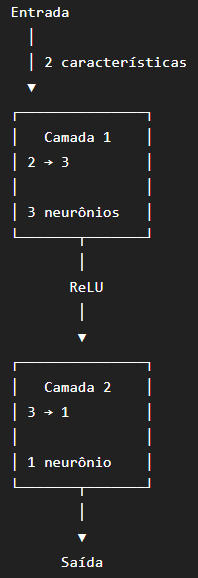

2 entradas

↓

3 neurônios

↓

1 saída

Queremos que o modelo aprenda: y = 2x₁ + 3x₂

In [13]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [2, 2],
    [3, 1],
    [1, 3]
], dtype=float)

y = np.array([
    [5],
    [7],
    [8],
    [10],
    [9],
    [11]
], dtype=float)

In [14]:
print("X:", X.shape)
print("y:", y.shape)

X: (6, 2)
y: (6, 1)


6 exemplos
×
2 características

Agora nossa rede terá: 2 → 3 → 1

In [15]:
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))

W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

In [16]:
print("W1:", W1.shape)
print("b1:", b1.shape)

print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (2, 3)
b1: (1, 3)
W2: (3, 1)
b2: (1, 1)


X
(6,2)
 │
 ▼
W1
(2,3)
 │
 ▼
Z1
(6,3)
 │
 ▼
ReLU
 │
 ▼
A1
(6,3)
 │
 ▼
W2
(3,1)
 │
 ▼
Z2
(6,1)
 │
 ▼
Previsão

Forward Pass

In [17]:
Z1 = X @ W1 + b1

In [18]:
A1 = np.maximum(0, Z1)

In [19]:
Z2 = A1 @ W2 + b2

In [20]:
y_pred = Z2

o fluxo:

X

↓

X @ W1 + b1

↓

Z1

↓

ReLU

↓

A1

↓

A1 @ W2 + b2

↓

Z2

↓

y_pred

Calculando o Loss com MSE:

In [21]:
loss = np.mean((y_pred - y) ** 2)

print("Loss:", loss)

Loss: 73.86015783203162


Agora com o Backpropagation, que percorre o caminho de trás pra frente querendo decobrir quanto cada peso contribuiu para o erro?

Usamos a regra da cadeia.

Loss

 ↓

Quanto a saída influenciou o Loss?

 ↓

Quanto os pesos influenciaram a saída?

 ↓

Quanto cada peso contribuiu para o erro?

Para o MSE:

In [22]:
dZ2 = (2 / len(X)) * (y_pred - y)

Esse gradiente nos diz: Como o erro muda quando a saída muda?

Agora precisamos calcular o gradiente de W2

A1 @ W2 = Z2

então:

In [23]:
dW2 = A1.T @ dZ2

e para o Bias:

In [24]:
db2 = np.sum(dZ2, axis=0, keepdims=True)

agora temos:

dW2

db2

assim voltamos para a camada anterior:

precisamos propagar o erro para trás

In [25]:
dA1 = dZ2 @ W2.T

Mas existe uma ReLU entre as camadas.

Precisamos considerar a derivada da ReLU.

A derivada é:

x > 0 → 1

x ≤ 0 → 0

In [26]:
dZ1 = dA1 * (Z1 > 0)

In [27]:
dW1 = X.T @ dZ1

In [28]:
db1 = np.sum(dZ1, axis=0, keepdims=True)

Agora temos todos os gradientes:

dW1

db1

dW2

db2

e assim podemos atualizar os pesos, usamos Gradient Descent:

In [29]:
learning_rate = 0.01

In [30]:
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

Forward Pass

      ↓
    
Loss

      ↓
Backpropagation

      ↓
Gradientes

      ↓
    
Gradient Descent


Agora treinamos a rede inteira:

In [31]:
import numpy as np

# Dados
X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [2, 2],
    [3, 1],
    [1, 3]
], dtype=float)

y = np.array([
    [5],
    [7],
    [8],
    [10],
    [9],
    [11]
], dtype=float)


# Inicialização dos pesos
np.random.seed(42)

W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))

W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))


# Configurações
learning_rate = 0.01
epochs = 5000

historico_loss = []


# Treinamento
for epoch in range(epochs):

    # ==========================
    # FORWARD PASS
    # ==========================

    Z1 = X @ W1 + b1

    A1 = np.maximum(0, Z1)

    Z2 = A1 @ W2 + b2

    y_pred = Z2


    # ==========================
    # LOSS
    # ==========================

    loss = np.mean((y_pred - y) ** 2)

    historico_loss.append(loss)


    # ==========================
    # BACKPROPAGATION
    # ==========================

    dZ2 = (2 / len(X)) * (y_pred - y)

    dW2 = A1.T @ dZ2

    db2 = np.sum(dZ2, axis=0, keepdims=True)


    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1

    db1 = np.sum(dZ1, axis=0, keepdims=True)


    # ==========================
    # ATUALIZAÇÃO
    # ==========================

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    # ==========================
    # MONITORAMENTO
    # ==========================

    if epoch % 500 == 0:

        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.6f}"
        )

Epoch: 0 | Loss: 72.446428
Epoch: 500 | Loss: 0.005950
Epoch: 1000 | Loss: 0.000095
Epoch: 1500 | Loss: 0.000001
Epoch: 2000 | Loss: 0.000000
Epoch: 2500 | Loss: 0.000000
Epoch: 3000 | Loss: 0.000000
Epoch: 3500 | Loss: 0.000000
Epoch: 4000 | Loss: 0.000000
Epoch: 4500 | Loss: 0.000000


e fazemos uma previsão:

In [32]:
nova_entrada = np.array([
    [4, 2]
], dtype=float)

Z1_novo = nova_entrada @ W1 + b1

A1_novo = np.maximum(0, Z1_novo)

previsao = A1_novo @ W2 + b2

print("Previsão:", previsao)

Previsão: [[14.00021281]]


2(4) + 3(2) = 14

Agora temos uma rede:

2 entradas

    │
    ▼
3 neurônios

    │
   ReLU

    │
    ▼
1 neurônio

    │
    ▼
Previsão

Implementamos manualmente:

✔ Forward Pass

✔ Função de ativação

✔ Loss

✔ Backpropagation

✔ Gradientes

✔ Gradient Descent

✔ Atualização de pesos

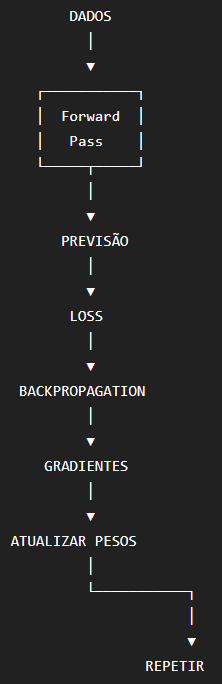

Visualizando o Loss:

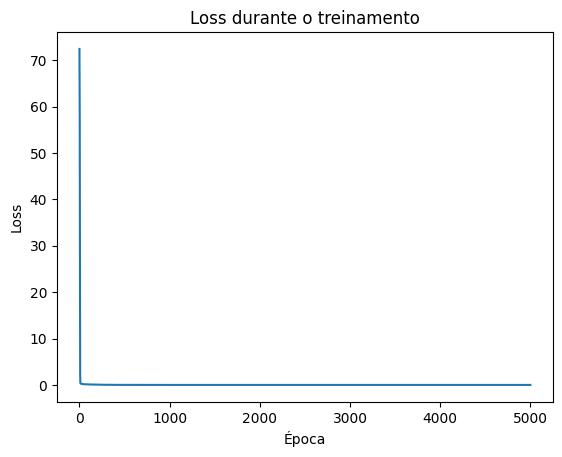

In [33]:
import matplotlib.pyplot as plt

plt.plot(historico_loss)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title("Loss durante o treinamento")

plt.show()

Testando novas entradas:

In [34]:
novas_entradas = np.array([
    [4, 2],
    [5, 3],
    [10, 1],
    [2, 5],
    [7, 4]
], dtype=float)

Z1_novas = novas_entradas @ W1 + b1

A1_novas = np.maximum(0, Z1_novas)

previsoes = A1_novas @ W2 + b2

print("Entradas:")
print(novas_entradas)

print("\nPrevisões:")
print(previsoes)

Entradas:
[[ 4.  2.]
 [ 5.  3.]
 [10.  1.]
 [ 2.  5.]
 [ 7.  4.]]

Previsões:
[[14.00021281]
 [19.00029021]
 [22.99834811]
 [19.00005807]
 [26.000445  ]]


Previsões:

14.x

19.x

23.x

19.x

26.x

Quanto mais próximo dos valores reais, melhor o modelo generalizou.

## ✅ Síntese do Notebook 05

Neste notebook, o treinamento foi construído manualmente. Isso revelou o que frameworks como TensorFlow automatizam:

1. **Forward pass:** produz previsões;
2. **Loss:** mede a diferença em relação aos alvos;
3. **Backpropagation:** calcula gradientes pela regra da cadeia;
4. **Gradient Descent:** atualiza pesos e biases;
5. **Repetição:** reduz progressivamente o erro.

A rede treinada também foi testada em exemplos não usados diretamente durante o ajuste, introduzindo a ideia de **generalização**.

### Perguntas de revisão

1. Por que elevar o erro ao quadrado no MSE?
2. O que acontece se o learning rate for muito alto?
3. Qual é o papel da derivada da ReLU no backpropagation?
4. Por que os shapes dos gradientes precisam ser iguais aos shapes dos parâmetros?

### Próximo notebook

No Notebook 06, reproduziremos esse fluxo com TensorFlow/Keras e avançaremos para divisão de dados, validação e normalização.
